## Final Submission Notebook
# Parallel Perspectives: Restoring an Image from 1D Data

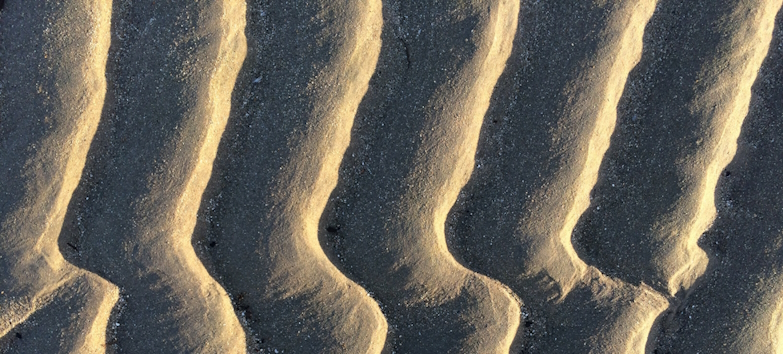

By Leo Dinendra March 15, 2024

--------

### Part 0 Getting Ready

In [ ]:
!pip install -r requirements.txt

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import json
import mmap

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, GroupShuffleSplit, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, make_scorer

np.seterr(invalid='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [2]:
test_file = './test_traces_250.json' #REPLACE THIS WITH THE HIDDEN TEST DATA FILE

### Part 1 Data Exploration & Ideas

**Summary / TL;DR** : I am creating a dataset of pairwise scores for seismic traces using Pearson product-moment correlation coefficients, utilize Machine Learning (Extra Trees) to predict potential corners, then reconstruct the seismic slice.

First let's load the training data

In [3]:
with open('./train.json', 'r', encoding="utf-8") as json_file:
    with mmap.mmap(json_file.fileno(), length=0, access=mmap.ACCESS_READ) as mmap_object:
        data = json.load(mmap_object)

# all slices id list
keys = list(data.keys())

# choose one of the images split into traces from the train dataset.
key = keys[0] 

# take correct order of traces for slice with chosen key
solution = data[key]['solution']

# take all traces for slice with chosen key
traces = data[key]['traces']

Let's check the first slice

In [4]:
i=1
key = keys[i]
traces = data[key]['traces']
solution = data[key]['solution']
solution_int = np.array([int(x) for x in solution])
img = np.vstack([traces[str(k)] for k in traces]).T

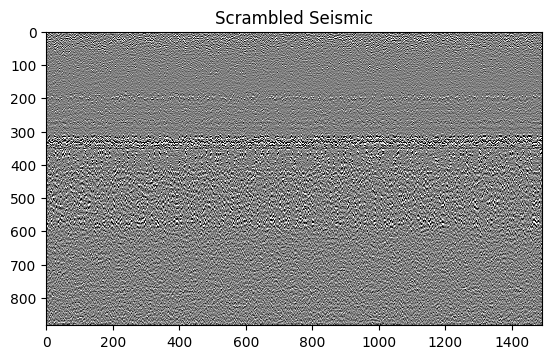

In [5]:
plt.imshow(img, interpolation='none', cmap='gray')
plt.title('Scrambled Seismic') 
plt.show()

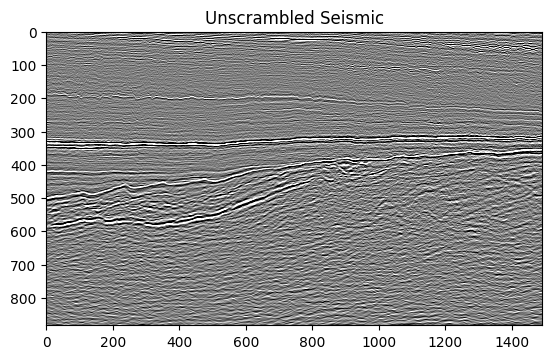

In [6]:
plt.imshow(img[:,solution_int], interpolation='none', cmap='gray')
plt.title('Unscrambled Seismic') 
plt.show()

Let's get the unscrambled slice and see the pairwise pearson correlation.

In [7]:
img_sol = img[:,solution_int]

In [8]:
pearson = np.corrcoef(img_sol.T)
pearson[np.isnan(pearson)]=-1

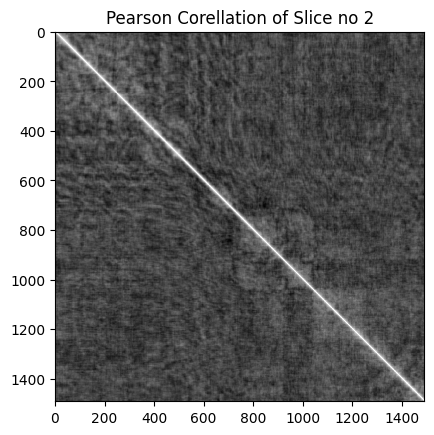

In [9]:
plt.imshow(pearson, interpolation='none', cmap='gray')
plt.title('Pearson Corellation of Slice no 2') 
plt.show()

Let's check the first trace pearson score (CORNER) compared to any other traces.

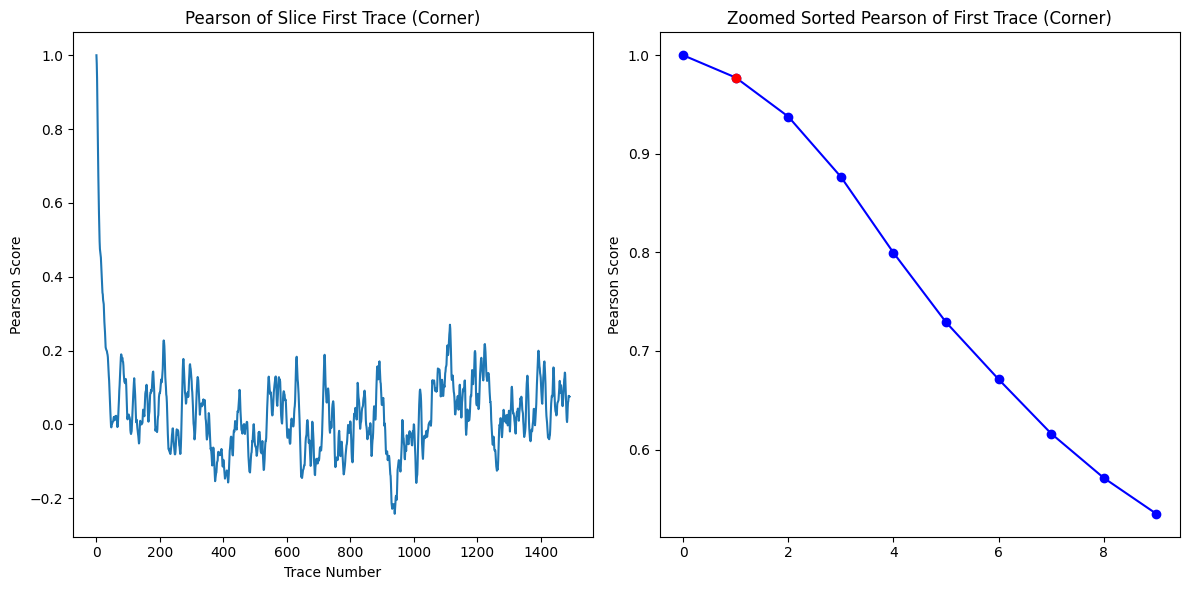

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(pearson[:, 0])
axs[0].set_title('Pearson of Slice First Trace (Corner)')
axs[0].set_ylabel('Pearson Score')
axs[0].set_xlabel('Trace Number')
axs[1].plot(np.arange(0,10), pearson[:10, 0], '-ob')
axs[1].plot(np.arange(1,2), pearson[1:2, 0], '-or')
axs[1].set_title('Zoomed Sorted Pearson of First Trace (Corner)')
axs[1].set_ylabel('Pearson Score')
plt.tight_layout()
plt.show()

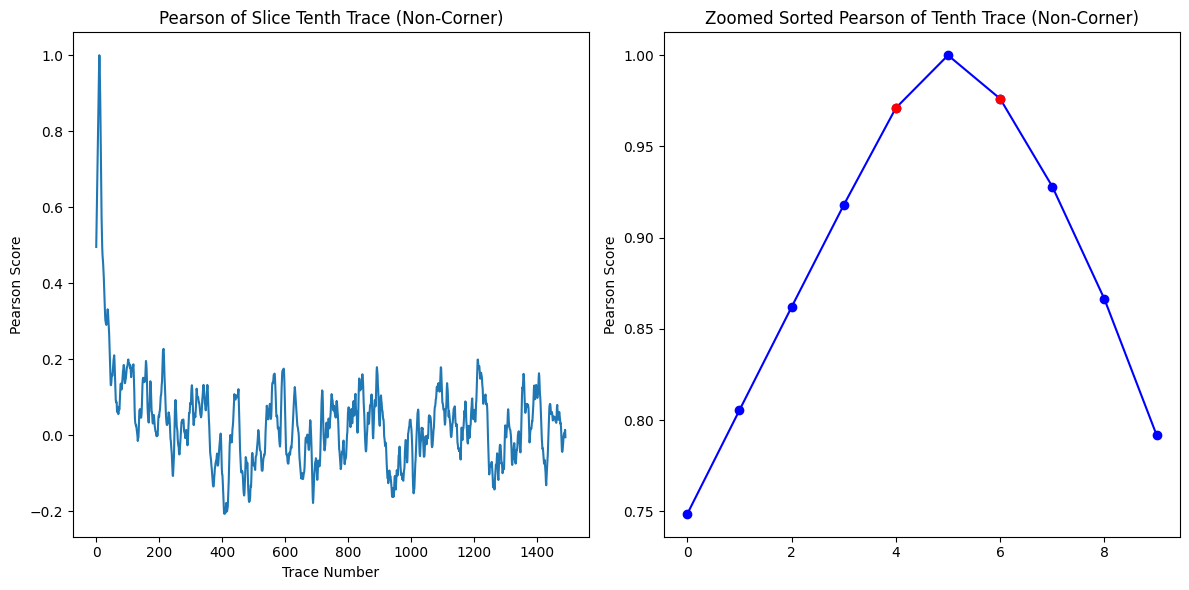

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(pearson[:, 10])
axs[0].set_title('Pearson of Slice Tenth Trace (Non-Corner)')
axs[0].set_ylabel('Pearson Score')
axs[0].set_xlabel('Trace Number')
axs[1].plot(np.arange(0,10), pearson[5:15, 10], '-ob')
axs[1].plot(np.arange(4,5), pearson[9, 10], '-or')
axs[1].plot(np.arange(6,7), pearson[11, 10], '-or')
axs[1].set_title('Zoomed Sorted Pearson of Tenth Trace (Non-Corner)')
axs[1].set_ylabel('Pearson Score')
plt.tight_layout()
plt.show()

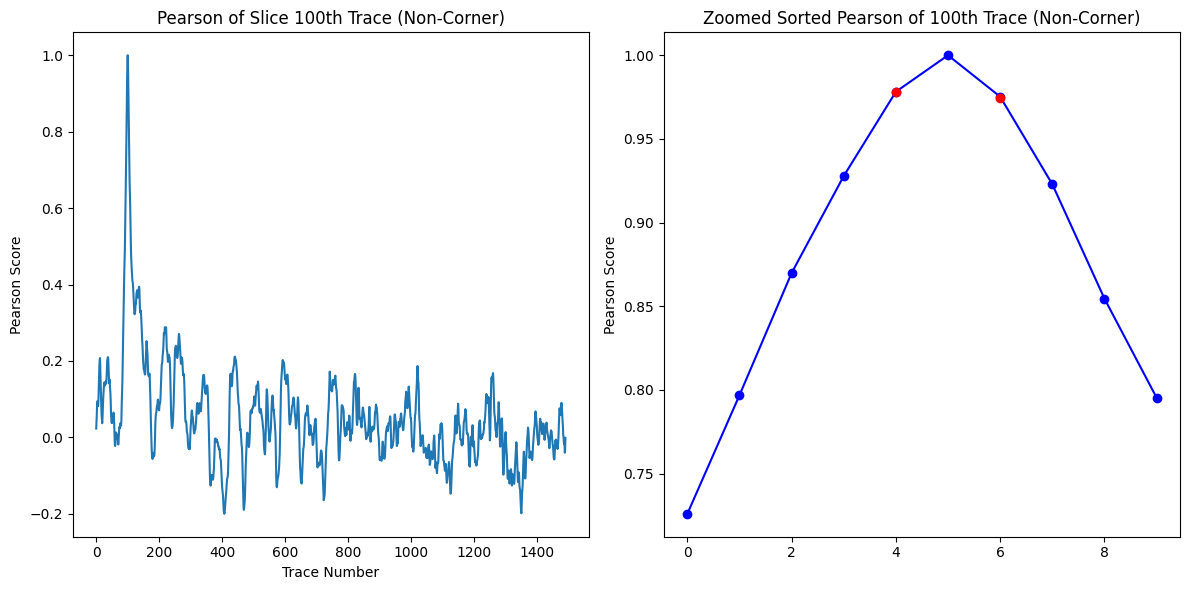

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(pearson[:, 100])
axs[0].set_title('Pearson of Slice 100th Trace (Non-Corner)')
axs[0].set_ylabel('Pearson Score')
axs[0].set_xlabel('Trace Number')
axs[1].plot(np.arange(0,10), pearson[95:105, 100], '-ob')
axs[1].plot(np.arange(4,5), pearson[99, 100], '-or')
axs[1].plot(np.arange(6,7), pearson[101, 102], '-or')
axs[1].set_title('Zoomed Sorted Pearson of 100th Trace (Non-Corner)')
axs[1].set_ylabel('Pearson Score')
plt.tight_layout()
plt.show()

As you can see, the differences between traces located in the corner and those not in the corner are as follows:
- There are two traces with a large correlation (red dots) to the trace that is not in the corner, whereas there is only one trace with such correlation for the trace in the corner.
- There are small score differences between the two largest correlation scores for the trace that is not in the corner.

However, these cases are only easily discernible when the data is sorted. 
When seismic data is in a scrambled state, we can only know from the pearson score difference, but what should be the threshold value?

Let's make the dataset and leave it to Machine Learning.

### Part 2 Dataset Making

In [13]:
def normalize_group(df, column):
    df[column] = (df[column] - df[column].min()) / (df[column].max() - df[column].min())
    return df

#### Train Dataset

In [14]:
# TRAIN DATASET
traindataset = pd.DataFrame(columns=['idkey', 'tracenum', 'delta_db1','delta_db2','delta_b1b2', 'solution', 'edge'])
for i in tqdm(range(len(keys))):
    key = keys[i]
    traces = data[key]['traces']
    solution = data[key]['solution']
    solution_int = np.array([int(x) for x in solution])
    img = np.vstack([traces[str(k)] for k in traces]).T
    dataexp = np.corrcoef(img.T)
    dataexp[np.isnan(dataexp)]=-1
    maxt = dataexp.shape[0]
    statdata = []
    for j in range(img.shape[1]):
        sample = dataexp[:,j]
        testid = np.flip(np.argsort(sample))
        datum = testid[0]
        best1 = testid[1]
        best2 = testid[2]
        delta_db1 = sample[datum]-sample[best1]
        delta_db2 = sample[datum]-sample[best2]
        delta_b1b2 = sample[best1]-sample[best2]
        sol = np.where(solution_int == datum)[0][0]
        statdata.append([key, datum, delta_db1, delta_db2, delta_b1b2, sol])
    statdata=pd.DataFrame(statdata, columns=['idkey', 'tracenum', 'delta_db1','delta_db2','delta_b1b2', 'solution'])
    statdata['edge']=0
    statdata.loc[statdata['solution'] == img.shape[1] - 1, 'edge'] = 1
    statdata.loc[statdata['solution'] == 0, 'edge'] = 1

    statdata = normalize_group(statdata, 'delta_db1')
    statdata = normalize_group(statdata, 'delta_db2')
    statdata = normalize_group(statdata, 'delta_b1b2')
    traindataset = pd.concat([traindataset, statdata], ignore_index=True)

100%|████████████████████████████████████████████████████████████████████████████████| 620/620 [02:31<00:00,  4.09it/s]


In [15]:
traindataset.head(5)

,idkey,tracenum,delta_db1,delta_db2,delta_b1b2,solution,edge
0,20231207113632957725,0,0.188299,0.164073,0.062303,1464,0
1,20231207113632957725,1,0.540721,0.480729,0.171572,1078,0
2,20231207113632957725,2,0.150846,0.147203,0.072425,108,0
3,20231207113632957725,3,0.116729,0.175248,0.137865,631,0
4,20231207113632957725,4,0.473087,0.354137,0.065359,1325,0


Ok, so basically we made dataset with features of the pearson score difference of datum trace vs 1st largest pearson score (**delta_db1**), difference of datum trace vs 2nd largest pearson score (**delta_db2**), and difference of 1st largest pearson score trace vs 2nd largest (**delta_b1b2**). The label **edge** where 1 mean it the trace is located in the corner.

and below are just identifier, not as features :
- idkey : id key of seismic slice
- tracenum : unsorted trace position
- solution : true trace position

Let's save the dataset.

In [16]:
traindataset.to_csv('train_dataset_edge_pearson.csv', index=False)

#### Test Dataset

In [17]:
with open(test_file, 'r', encoding="utf-8") as json_file:
    with mmap.mmap(json_file.fileno(), length=0, access=mmap.ACCESS_READ) as mmap_object:
        data = json.load(mmap_object)

# all slices id list
keys = list(data.keys())

# choose one of the images split into traces from the train dataset.
key = keys[0] 

# take all traces for slice with chosen key
traces = data[key]['traces']

In [18]:
testdataset = pd.DataFrame(columns=['idkey', 'tracenum', 'delta_db1','delta_db2','delta_b1b2'])
for i in tqdm(range(len(keys))):
    key = keys[i]
    traces = data[key]['traces']
    img = np.vstack([traces[str(k)] for k in traces]).T
    dataexp = np.corrcoef(img.T)
    if np.any(np.isnan(dataexp)):
        dataexp[np.isnan(dataexp)]=-1
    maxt = dataexp.shape[0]
    statdata = []
    for j in range(img.shape[1]):
        sample = dataexp[:,j]
        testid = np.flip(np.argsort(sample))
        datum = testid[0]
        best1 = testid[1]
        best2 = testid[2]
        delta_db1 = sample[datum]-sample[best1]
        delta_db2 = sample[datum]-sample[best2]
        delta_b1b2 = sample[best1]-sample[best2]
        statdata.append([key, datum, delta_db1, delta_db2, delta_b1b2])
    statdata=pd.DataFrame(statdata, columns=['idkey', 'tracenum', 'delta_db1','delta_db2','delta_b1b2'])

    statdata = normalize_group(statdata, 'delta_db1')
    statdata = normalize_group(statdata, 'delta_db2')
    statdata = normalize_group(statdata, 'delta_b1b2')
    testdataset = pd.concat([testdataset, statdata], ignore_index=True)

100%|████████████████████████████████████████████████████████████████████████████████| 250/250 [00:26<00:00,  9.28it/s]


In [19]:
testdataset.head(5)

,idkey,tracenum,delta_db1,delta_db2,delta_b1b2
0,20231207113916617082,0,0.229573,0.138107,0.004177
1,20231207113916617082,1,0.141819,0.086580,0.009394
2,20231207113916617082,2,0.202316,0.134756,0.021714
3,20231207113916617082,3,0.175724,0.115891,0.019206
4,20231207113916617082,4,0.196927,0.117664,0.004514


In [20]:
testdataset.to_csv('test_dataset_edge_pearson.csv', index=False)

### Part 3 ML Model Training

In [21]:
train_dataset = pd.read_csv('train_dataset_edge_pearson.csv')

In [22]:
group_splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=83355)

for train_index, test_index in group_splitter.split(train_dataset[['delta_db1','delta_db2','delta_b1b2']], train_dataset[['edge']], groups=train_dataset['idkey']):
    X_train, X_test = train_dataset[['delta_db1','delta_db2','delta_b1b2']].iloc[train_index], train_dataset[['delta_db1','delta_db2','delta_b1b2']].iloc[test_index]
    y_train, y_test = train_dataset['edge'].iloc[train_index], train_dataset['edge'].iloc[test_index]

In [23]:
# Create and train the Extra Trees model based on parameter that has been optimized
model = ExtraTreesClassifier(n_estimators=50, max_depth=None, random_state=83355)
model.fit(X_train, y_train)

ExtraTreesClassifier(n_estimators=50, random_state=83355)

In [24]:
# Make predictions on the test set
y_pred = model.predict(X_test)

In [25]:
# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.9993232938419739
Precision: 0.8313953488372093
Recall: 0.5766129032258065
F1 Score: 0.680952380952381


### Part 4 Prediction & Submission

#### Corner Prediction

In [26]:
test_dataset = pd.read_csv('test_dataset_edge_pearson.csv')

In [27]:
# Make predictions on the test set
test_pred = model.predict(test_dataset[['delta_db1','delta_db2','delta_b1b2']])

In [28]:
test_predprob = model.predict_proba(test_dataset[['delta_db1','delta_db2','delta_b1b2']])

In [29]:
test_dataset['pred_edge'] = test_pred
test_dataset['pred_edgeprob_0'] = test_predprob[:,0]
test_dataset['pred_edgeprob_1'] = test_predprob[:,1]

In [30]:
test_dataset

,idkey,tracenum,delta_db1,delta_db2,delta_b1b2,pred_edge,pred_edgeprob_0,pred_edgeprob_1
0,20231207113916617082,0,0.229573,0.138107,0.004177,0,1.0,0.0
1,20231207113916617082,1,0.141819,0.086580,0.009394,0,1.0,0.0
2,20231207113916617082,2,0.202316,0.134756,0.021714,0,1.0,0.0
3,20231207113916617082,3,0.175724,0.115891,0.019206,0,1.0,0.0
4,20231207113916617082,4,0.196927,0.117664,0.004514,0,1.0,0.0
...,...,...,...,...,...,...,...,...
231796,20231207114118772907,2105,0.201493,0.114928,0.037784,0,1.0,0.0
231797,20231207114118772907,2106,0.344756,0.217857,0.088393,0,1.0,0.0
231798,20231207114118772907,2107,0.262394,0.117469,0.004156,0,1.0,0.0
231799,20231207114118772907,2108,0.163155,0.070150,0.001185,0,1.0,0.0


In [31]:
anchor_df = test_dataset.sort_values(by=['pred_edgeprob_1'], ascending=False).drop_duplicates(subset='idkey')

In [32]:
anchor_df

,idkey,tracenum,delta_db1,delta_db2,delta_b1b2,pred_edge,pred_edgeprob_0,pred_edgeprob_1
135048,20231207114012842162,687,0.125293,1.000000,1.000000,1,0.00,1.00
109315,20231207114001876454,875,0.309467,1.000000,1.000000,1,0.00,1.00
48950,20231207113937234279,600,0.343043,1.000000,1.000000,1,0.00,1.00
156807,20231207114022511343,185,0.094485,1.000000,1.000000,1,0.00,1.00
7247,20231207113918808478,640,0.384858,1.000000,1.000000,1,0.00,1.00
...,...,...,...,...,...,...,...,...
163771,20231207114024549389,593,0.142412,0.534093,0.583174,0,0.66,0.34
177469,20231207114035187291,234,0.604535,1.000000,1.000000,0,0.72,0.28
109453,20231207114001912092,117,0.888019,1.000000,1.000000,0,0.72,0.28
65663,20231207113944206429,63,0.617346,1.000000,1.000000,0,0.80,0.20


In [33]:
anchor_df['idkey'].nunique()

250

In [34]:
anchor_df[['idkey','tracenum']].to_csv('test_result_edge_pearson.csv', index=False)

#### Reconstruction

In [35]:
test_mlpred = pd.read_csv('test_result_edge_pearson.csv')

Once we found predicted corner/anchor, it's quite straighforward to rearrange the trace by choosing the largest pairwise Pearson product-moment correlation coefficients for each trace. Problem will arise when we face an **anomaly/padding trace** - a trace that has constant amplitude. As it is impossible to know exactly where the true location unless we have already seen it in the training data, we just put those amplitude to the rest of reconstructed seismic slice. 

In [36]:
#standart solution, stack first
solution_json = {}
for i in tqdm(range(0, len(keys))):
    key = keys[i]
    traces = data[key]['traces']
    img = np.vstack([traces[str(k)] for k in traces]).T
    dataexp = np.corrcoef(img.T)
    if np.any(np.isnan(dataexp)):
        dataexp[np.isnan(dataexp)]=-1
    statdata = []
    for j in range(img.shape[1]):
        sample = dataexp[:,j]
        testid = np.argsort(sample)
        best1 = testid[-2]
        best2 = testid[-3]
        best3 = testid[-4]
        best4 = testid[-5]
        dbest = sample[best1]-sample[best2]
        statdata.append([best1, best2, best3, best4, dbest])

    statdata=pd.DataFrame(statdata, columns=['best1','best2','best3','best4','delta'])
    statdata.sort_values(by=['delta'], ascending=False, inplace=True)
    solution=[]
    flag = np.linspace(0,img.shape[1]-1,img.shape[1],dtype='int32').tolist()
    idstart = test_mlpred['tracenum'][test_mlpred['idkey']==key].values[0]
    solution.append(idstart)
    flag.remove(idstart)
    for j in range(len(statdata.loc[idstart])):
        if int(statdata.loc[idstart][j]) not in solution:
            idstart = int(statdata.loc[idstart][j])
            break
    solution.append(idstart)
    flag.remove(idstart)
    while flag:
        if statdata.loc[idstart][0] not in solution:
            result = int(statdata.loc[idstart][0])
            solution.append(result)
            flag.remove(result)
            idstart = result
        elif statdata.loc[idstart][1] not in solution:
            result = int(statdata.loc[idstart][1])
            solution.append(result)
            flag.remove(result)
            idstart = result
        elif statdata.loc[idstart][2] not in solution:
            result = int(statdata.loc[idstart][2])
            solution.append(result)
            flag.remove(result)
            idstart = result
        elif statdata.loc[idstart][3] not in solution:
            result = int(statdata.loc[idstart][3])
            solution.append(result)
            flag.remove(result)
            idstart = result
        else:
            print("padding trace found! placing to remaining solution")
            solution = flag + solution  
            flag = []
    
    #UNCOMMENT IF YOU WANT TO SAVE THE RECONSTRUCTED IMAGE TOO
    #fname = './outputpic/' + '%05d'%(i+1) + '_' + key + '.png'
    #plt.imsave(fname, img[:,solution], cmap='gray')
    
    solution = list(map(str, solution)) 
    solution_json[key]={
                'solution': solution
            }

 10%|████████▍                                                                        | 26/250 [00:05<00:42,  5.27it/s]

padding trace found! placing to remaining solution


 13%|██████████▋                                                                      | 33/250 [00:06<00:38,  5.70it/s]

padding trace found! placing to remaining solution


 14%|███████████                                                                      | 34/250 [00:06<00:43,  4.94it/s]

...

 82%|█████████████████████████████████████████████████████████████████▌              | 205/250 [00:41<00:10,  4.11it/s]

padding trace found! placing to remaining solution


 86%|████████████████████████████████████████████████████████████████████▍           | 214/250 [00:43<00:09,  3.70it/s]

padding trace found! placing to remaining solution


100%|████████████████████████████████████████████████████████████████████████████████| 250/250 [01:11<00:00,  3.48it/s]


#### Making Submission

In [37]:
with open('submission.json', 'w', encoding="utf-8") as f:
        json.dump(solution_json, f)

---------